# 02. Monetary policy vs central-bank information shocks (Fed and ECB)

**Question.** What do Fed and ECB announcements do to output, prices and stock markets, once we separate a
*monetary policy* surprise from a *central-bank information* surprise (the market learning something about the economy from the central bank)?

**Identification.** High-frequency surprises around announcements (Jarocinski-Karadi 2020, updated series, built from
the Altavilla et al. EA-MPD data for the ECB). The shocks come from sign restrictions on the co-movement of interest-rate and stock-price surprises in a narrow window:
- *Monetary policy shock*: rates up, stocks down.
- *Central-bank information shock*: rates up, stocks up (the market reads a stronger outlook).

**Estimation.** Local projections (Jorda 2005) with Newey-West standard errors. Shocks are standardised to 1 s.d.
This project extends the thesis question on the impact of Fed and ECB policy on stock returns.

**Limits.** The shocks are measured, not assumed exogenous, but they are generated regressors, and macro outcomes are the latest data vintage. Bands are 68% and 90% HAC intervals; with a few hundred monthly observations, wide bands mean the response is imprecisely estimated.

In [1]:
import sys, warnings
sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from data_utils import fred, ecb, DATA_DIR
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})

def month_end(s):
    s = s.copy(); s.index = s.index.to_period("M").to_timestamp("M"); return s[~s.index.duplicated(keep="last")]

def shocks(path):
    d = pd.read_csv(DATA_DIR / path)
    d.index = pd.to_datetime(dict(year=d.year, month=d.month, day=1)).dt.to_period("M").dt.to_timestamp("M")
    return d

jk_fed, jk_ecb = shocks("jk_fed_m.csv"), shocks("jk_ecb_m.csv")
for name, d in [("Fed", jk_fed), ("ECB", jk_ecb)]:
    nz = (d[["MP_median", "CBI_median"]].abs().sum(axis=1) > 0).sum()
    print(f"{name}: {d.index[0].date()} -> {d.index[-1].date()}, {nz} months with a non-zero shock")
print("corr(MP, pc1) Fed:", round(jk_fed.MP_median.corr(jk_fed.pc1_hf), 2), "| corr(CBI, stock surprise) Fed:", round(jk_fed.CBI_median.corr(jk_fed.SP500_hf), 2))

Fed: 1990-02-28 -> 2026-03-31, 298 months with a non-zero shock
ECB: 1999-01-31 -> 2025-10-31, 277 months with a non-zero shock
corr(MP, pc1) Fed: 0.88 | corr(CBI, stock surprise) Fed: 0.42


## 1. Outcomes
US: industrial production, CPI, 1-year Treasury yield, S&P 500. Euro area: industrial production, HICP, 2-year AAA yield, Euro Stoxx 50.

In [2]:
import yfinance as yf
def stock(ticker, fname):
    p = DATA_DIR / fname
    if not p.exists():
        px = yf.download(ticker, start="1990-01-01", interval="1mo", auto_adjust=True, progress=False)
        px = px["Close"] if "Close" in px else px
        px = px.squeeze(); px.name = ticker; px.to_csv(p)
    s = pd.read_csv(p, index_col=0, parse_dates=True).iloc[:, 0]
    return month_end(s.dropna())

us = pd.DataFrame({"IP": np.log(month_end(fred("INDPRO"))) * 100,
                   "CPI": np.log(month_end(fred("CPIAUCSL"))) * 100,
                   "Stocks": np.log(stock("^GSPC", "yf_gspc_m.csv")) * 100})
us["Yield 1y (pp)"] = month_end(fred("GS1"))
ea_ip = ecb("STS", "M.I9.Y.PROD.NS0020.4.000"); ea_cpi = ecb("ICP", "M.U2.N.000000.4.INX")
ea = pd.DataFrame({"IP": np.log(month_end(ea_ip)) * 100, "HICP": np.log(month_end(ea_cpi)) * 100,
                   "Stocks": np.log(stock("^STOXX50E", "yf_stoxx50_m.csv")) * 100})
try:
    y2 = ecb("YC", "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y")
    ea["Yield 2y (pp)"] = y2.resample("ME").mean()
except Exception as e:
    print("2y AAA yield not available:", e)
for name, d in [("US", us), ("Euro area", ea)]:
    print(name, {c: (d[c].first_valid_index().date(), d[c].last_valid_index().date()) for c in d})

US {'IP': (datetime.date(1950, 1, 31), datetime.date(2026, 8, 31)), 'CPI': (datetime.date(1950, 1, 31), datetime.date(2026, 8, 31)), 'Stocks': (datetime.date(1990, 1, 31), datetime.date(2026, 10, 31)), 'Yield 1y (pp)': (datetime.date(1953, 4, 30), datetime.date(2026, 9, 30))}
Euro area {'IP': (datetime.date(1991, 1, 31), datetime.date(2025, 9, 30)), 'HICP': (datetime.date(1996, 1, 31), datetime.date(2025, 12, 31)), 'Stocks': (datetime.date(2007, 3, 31), datetime.date(2026, 9, 30)), 'Yield 2y (pp)': (datetime.date(2004, 9, 30), datetime.date(2026, 9, 30))}


## 2. Local projections
For each horizon h: y(t+h) - y(t-1) = a + b_h * shock(t) + controls, with 6 lags of both shocks and of the outcome's monthly change.

In [3]:
def lp(y, sh, H=36, nlags=6, start=None, end=None):
    """Return DataFrame of b_h for each shock with 68/90% bands. sh: DataFrame with columns MP, CBI (standardised)."""
    d = pd.concat([y.rename("y"), sh], axis=1)
    if start: d = d.loc[start:]
    if end: d = d.loc[:end]
    out = {c: [] for c in sh.columns}
    for h in range(H + 1):
        dep = d["y"].shift(-h) - d["y"].shift(1)
        Z = pd.DataFrame(index=d.index)
        for c in sh.columns: Z[c] = d[c]
        for k in range(1, nlags + 1):
            for c in sh.columns: Z[f"{c}_l{k}"] = d[c].shift(k)
            Z[f"dy_l{k}"] = d["y"].diff().shift(k)
        D = pd.concat([dep.rename("dep"), Z], axis=1).dropna()
        if len(D) < 60:
            for c in sh.columns: out[c].append((h, np.nan, np.nan, np.nan, np.nan, np.nan)); continue
        m = sm.OLS(D["dep"], sm.add_constant(D.drop(columns="dep"))).fit(cov_type="HAC", cov_kwds={"maxlags": max(h, 1) + 1})
        for c in sh.columns:
            b, se = m.params[c], m.bse[c]
            out[c].append((h, b, b - 1.645 * se, b + 1.645 * se, b - 1.0 * se, b + 1.0 * se))
    return {c: pd.DataFrame(v, columns=["h", "b", "lo90", "hi90", "lo68", "hi68"]).set_index("h") for c, v in out.items()}

def std_shocks(d, a="MP_median", b="CBI_median", start=None, end=None):
    s = d[[a, b]].rename(columns={a: "MP", b: "CBI"})
    if start: s = s.loc[start:]
    if end: s = s.loc[:end]
    return s / s[s != 0].std()

def plot_irf(res, title, ylabels, fname, H):
    n = len(res)
    fig, axes = plt.subplots(2, n, figsize=(3.3 * n, 5.2), sharex=True)
    for j, (var, r) in enumerate(res.items()):
        for i, (shock, col) in enumerate([("MP", "#c0392b"), ("CBI", "#1f6f8b")]):
            ax = axes[i, j]; z = r[shock]
            ax.fill_between(z.index, z.lo90, z.hi90, color=col, alpha=.15); ax.fill_between(z.index, z.lo68, z.hi68, color=col, alpha=.30)
            ax.plot(z.index, z.b, color=col, lw=1.8); ax.axhline(0, color="k", lw=.8)
            if i == 0: ax.set_title(var)
            if j == 0: ax.set_ylabel({"MP": "Monetary policy shock", "CBI": "CB information shock"}[shock])
            if i == 1: ax.set_xlabel("months")
    fig.suptitle(title, y=1.0); plt.tight_layout(); plt.savefig(fname, bbox_inches="tight"); plt.show()

### 2a. Fed (from 1990)

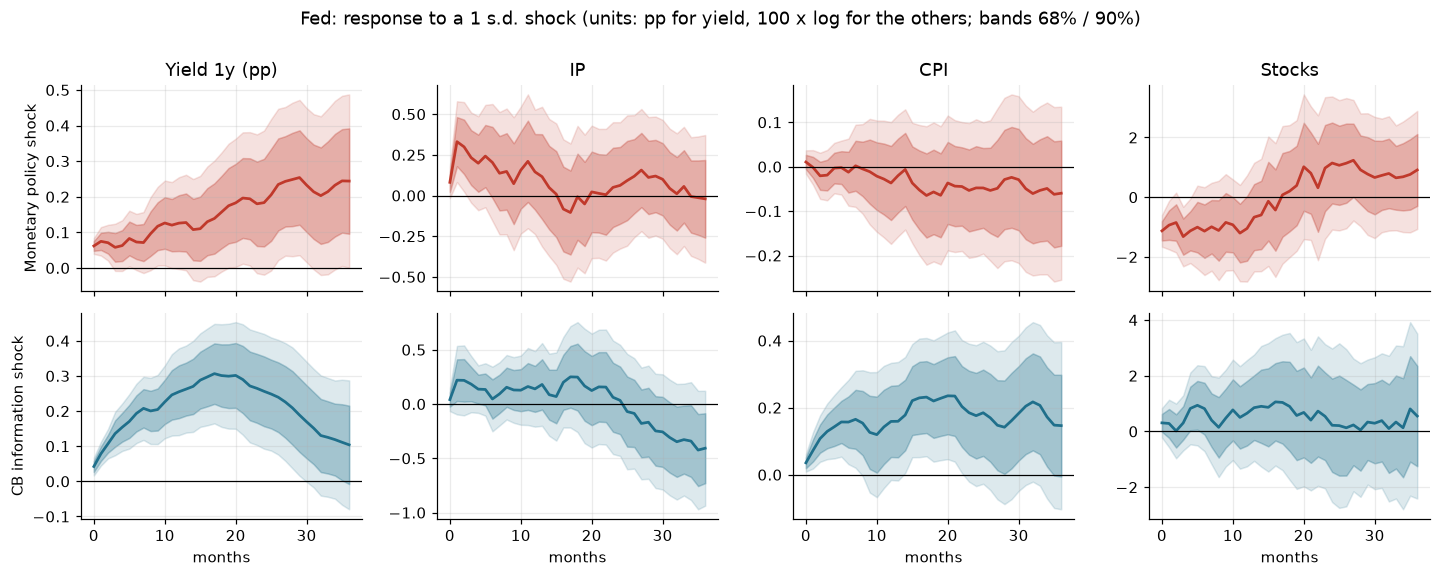

In [4]:
H = 36
sh_fed = std_shocks(jk_fed, end="2023-12-31")
res_fed = {v: lp(us[v].dropna(), sh_fed, H=H, start="1990-01") for v in ["Yield 1y (pp)", "IP", "CPI", "Stocks"]}
plot_irf(res_fed, "Fed: response to a 1 s.d. shock (units: pp for yield, 100 x log for the others; bands 68% / 90%)", None, "figures/02_irf_fed.png", H)

### 2b. ECB (from 1999)

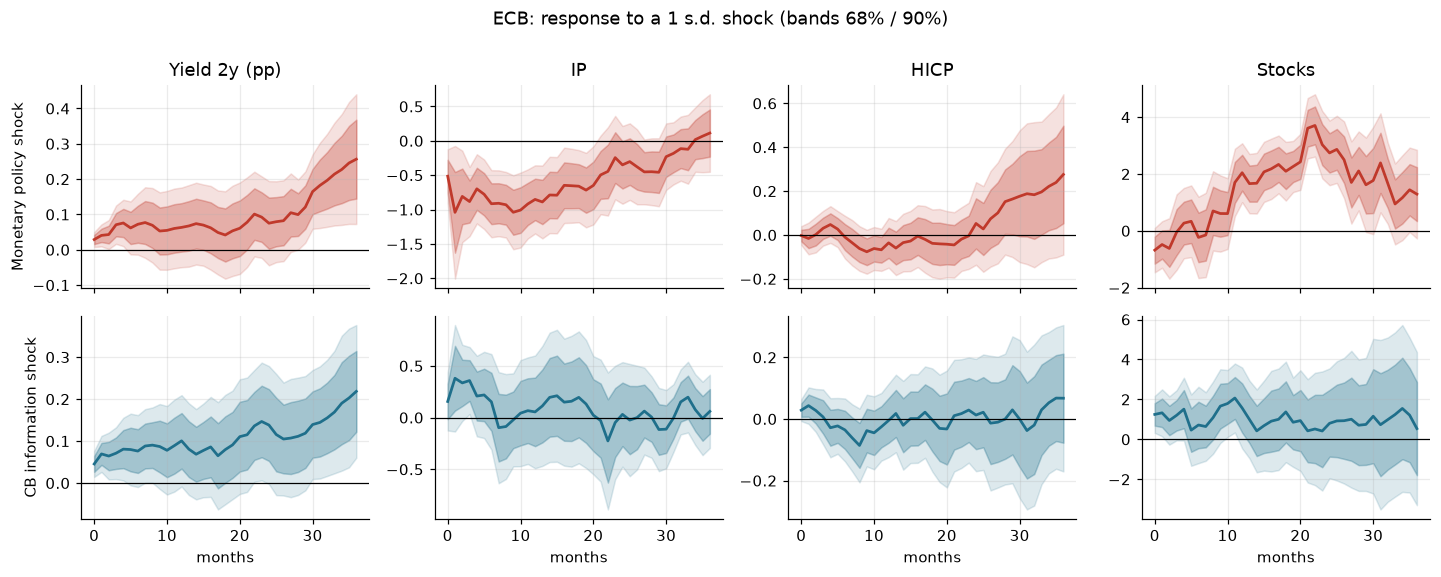

In [5]:
sh_ecb = std_shocks(jk_ecb, end="2023-12-31")
vars_ecb = [v for v in ["Yield 2y (pp)", "IP", "HICP", "Stocks"] if v in ea.columns]
res_ecb = {v: lp(ea[v].dropna(), sh_ecb, H=H, start="1999-01") for v in vars_ecb}
plot_irf(res_ecb, "ECB: response to a 1 s.d. shock (bands 68% / 90%)", None, "figures/02_irf_ecb.png", H)

## 3. Summary table
Response at fixed horizons (impact month, 12 and 24 months). `*` = the 90% band excludes zero.
Horizons are set in advance, so the table does not pick the largest point on each curve.

In [6]:
def summary(res, region, horizons=(0, 12, 24)):
    rows = []
    for var, r in res.items():
        for shock in ("MP", "CBI"):
            z = r[shock]; row = {"region": region, "outcome": var, "shock": shock}
            for h in horizons:
                star = "*" if (z.lo90[h] > 0 or z.hi90[h] < 0) else ""
                row[f"h={h}"] = f"{z.b[h]:+.2f}{star}"
            rows.append(row)
    return pd.DataFrame(rows)
tab = pd.concat([summary(res_fed, "Fed"), summary(res_ecb, "ECB")], ignore_index=True)
tab.to_csv("data/out_02_summary.csv", index=False); tab

,region,outcome,shock,h=0,h=12,h=24
0,Fed,Yield 1y (pp),MP,+0.06*,+0.13,+0.18
1,Fed,Yield 1y (pp),CBI,+0.04*,+0.25*,+0.26*
2,Fed,IP,MP,+0.08,+0.15,+0.06
3,Fed,IP,CBI,+0.04,+0.14,+0.03
4,Fed,CPI,MP,+0.01,-0.04,-0.05
5,Fed,CPI,CBI,+0.04*,+0.16,+0.18
6,Fed,Stocks,MP,-1.13*,-1.05,+1.14
7,Fed,Stocks,CBI,+0.31,+0.65,+0.22
8,ECB,Yield 2y (pp),MP,+0.03*,+0.06,+0.08
9,ECB,Yield 2y (pp),CBI,+0.05*,+0.10,+0.14


## 4. Robustness: 2009-2015 excluded (zero lower bound period)
Near the zero lower bound, short-rate surprises are mechanically small. We re-estimate the Fed output and stock responses after dropping 2009-2015 observations of the outcome variable; the shock series is unchanged.

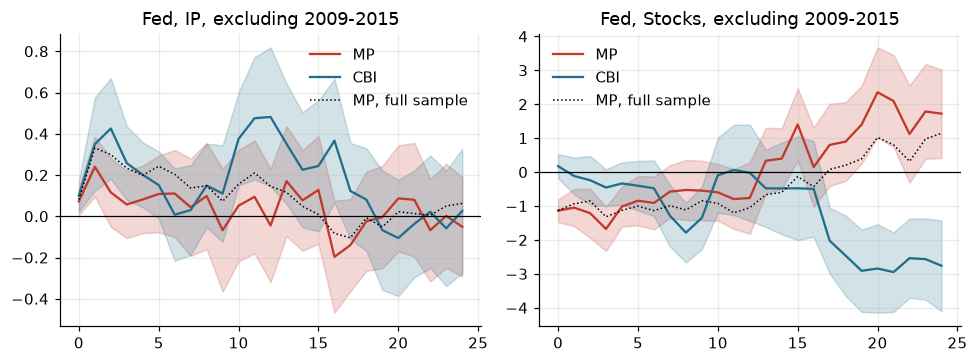

In [7]:
def lp_mask(y, sh, H, drop=("2009-01-31", "2015-12-31")):
    ym = y.copy(); ym.loc[drop[0]:drop[1]] = np.nan
    return lp(ym, sh, H=H)

rob = {v: lp_mask(us[v].dropna(), sh_fed, 24) for v in ["IP", "Stocks"]}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, (v, r) in zip(axes, rob.items()):
    for shock, col in [("MP", "#c0392b"), ("CBI", "#1f6f8b")]:
        z = r[shock]; ax.plot(z.index, z.b, color=col, label=shock); ax.fill_between(z.index, z.lo68, z.hi68, color=col, alpha=.2)
    base = res_fed[v]["MP"]; ax.plot(base.index[:25], base.b[:25], color="k", ls=":", lw=1, label="MP, full sample")
    ax.axhline(0, color="k", lw=.8); ax.set_title(f"Fed, {v}, excluding 2009-2015"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("figures/02_robustness_zlb.png"); plt.show()

## 5. What to check when reading
- Does a monetary policy shock move stocks *down* and the information shock *up*? That sign pattern is the point of the decomposition; a standard single-shock approach would average the two and blur the stock response.
- Are output and price responses distinguishable from zero? With ~400 observations, usually only partly. The bands give the precision.
- The ZLB robustness plot shows whether the result depends on the 2009-2015 period.

**Extensions.** Add a VAR with these shocks as external instruments (proxy-SVAR), state-dependent LPs (recession vs expansion), and sectoral stock responses.